In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from time import time_ns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
print(f"Currently using {DEVICE}")

Currently using cuda


In [4]:
from src.data_import import *

train_loader, test_loader, _ = load_lfw(batch_size=BATCH_SIZE, shuffle=True)

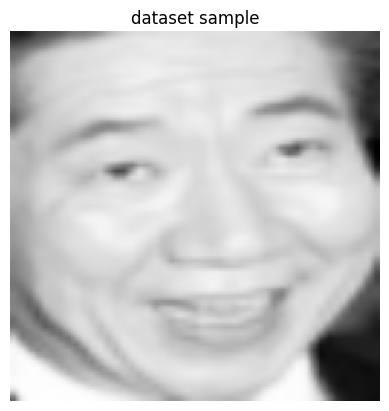

label: 50
shape: torch.Size([16, 1, 128, 128])


In [5]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="Grays")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [6]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 4
IMAGE_SHAPE = (1, 128, 128)

model = EBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=BATCH_SIZE)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-3): 4 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=65536, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [ ]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=16, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [8]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.000, 0.999))

for epoch in range(15):
    epoch_loss, _ = train_one_epoch_TC(
        model, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=50,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=1e-2,
        
        tc_estimator=total_correlation_estimator,
        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    if epoch % 5 == 0:
        torch.save(model.state_dict(), f"./models/lfw/EBM_{epoch}_epochs_{len(model.heads)}_heads_{time_ns()}t.pth")


  0%|          | 0/152 [00:00<?, ?it/s]

100%|██████████| 152/152 [05:05<00:00,  2.01s/it]


  CD:     -0.0316
  Reg:    0.1760
  Corr:   0.0041
  E_real: -0.0222
  E_fake: 0.0094
  Gap:    -0.0316
Epoch 1, Loss: 0.1485


100%|██████████| 152/152 [05:07<00:00,  2.02s/it]


  CD:     -0.0148
  Reg:    0.0077
  Corr:   0.0025
  E_real: -0.0296
  E_fake: -0.0148
  Gap:    -0.0148
Epoch 2, Loss: -0.0046


...

  CD:     -0.0030
  Reg:    0.0031
  Corr:   3.3084
  E_real: -0.0006
  E_fake: 0.0023
  Gap:    -0.0030
Epoch 13, Loss: 3.3085


100%|██████████| 152/152 [05:07<00:00,  2.02s/it]


  CD:     -0.0014
  Reg:    0.0023
  Corr:   3.8233
  E_real: -0.0014
  E_fake: -0.0000
  Gap:    -0.0014
Epoch 14, Loss: 3.8242


100%|██████████| 152/152 [05:07<00:00,  2.02s/it]

  CD:     -0.0006
  Reg:    0.0028
  Corr:   4.3621
  E_real: 0.0019
  E_fake: 0.0025
  Gap:    -0.0006
Epoch 15, Loss: 4.3643


EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=-0.2684,  std=0.0166
  Test   →  mean=-0.2693,  std=0.0168
  |E_test - E_train| = 0.0009  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.2779,  std=0.0249
  Gap (E_real_train - E_fake) = 0.0095  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=8.7957,  std=0.0637
  Gap (E_real_train - E_noise) = -9.0641  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=0.2301,  std=0.0440
  Head 1  →  mean=-0.0104,  std=0.0808
  Head 2  →  mean=0.0292,  std=0.0432
  Head 3  →  mean=-0.5200,  std=0.0180
  Max off-diagonal correlation: 0.9765  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.0080,  std=0.1814,  min=-0.7323,  max=0.8339

[6] Visual samples (Langevin from noise)


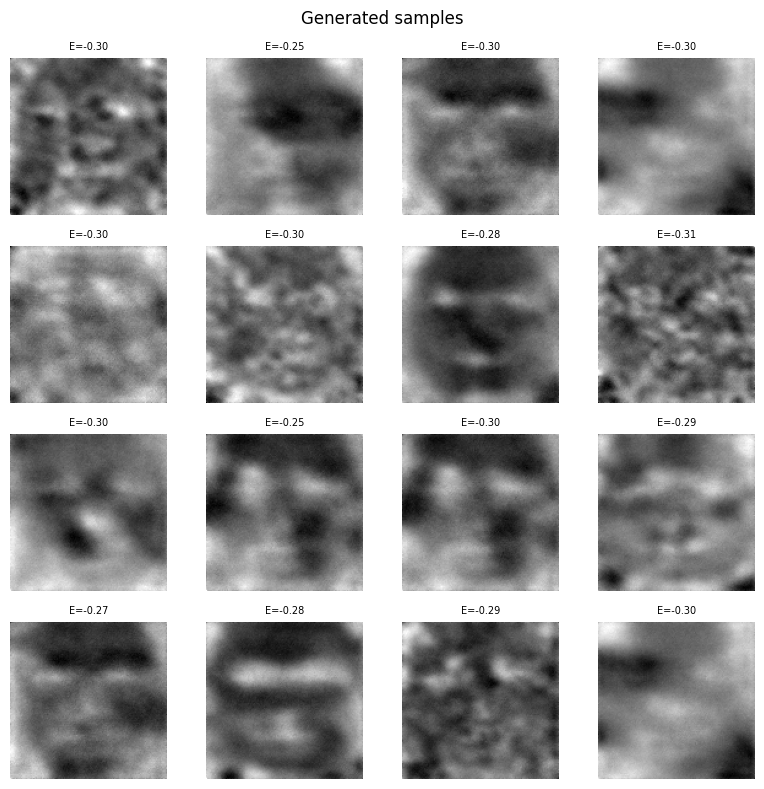


DONE


In [9]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

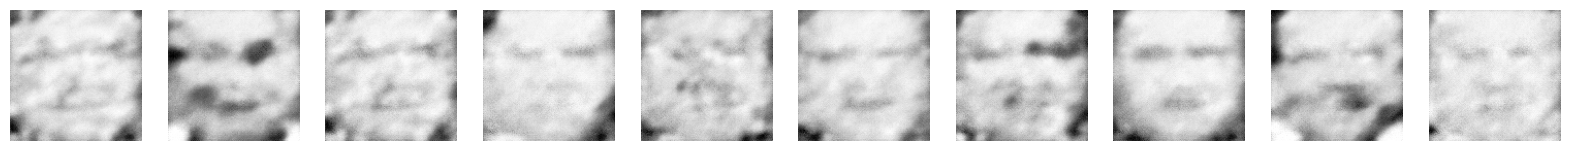

In [ ]:
show_grid(samples, 10, cmap="Grays")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x3136 and 65536x49)

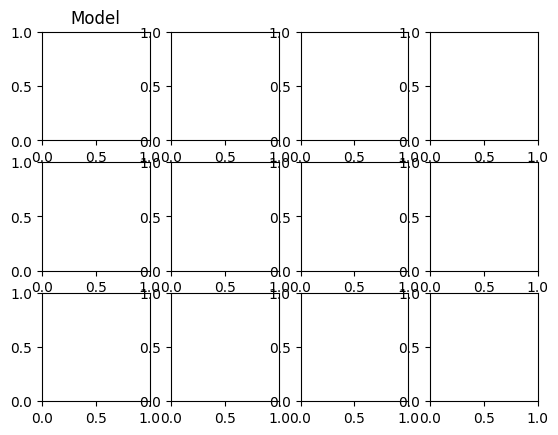

In [ ]:
# from src.plot import visualize_heads

# model.to("cpu")

# fig = visualize_heads(
#     model, 
#     steps=200, 
#     step_size=10.0, 
#     noise_std=0.01,
#     k=3,
#     cmap="Grays",
# )

# model.to(DEVICE)

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()

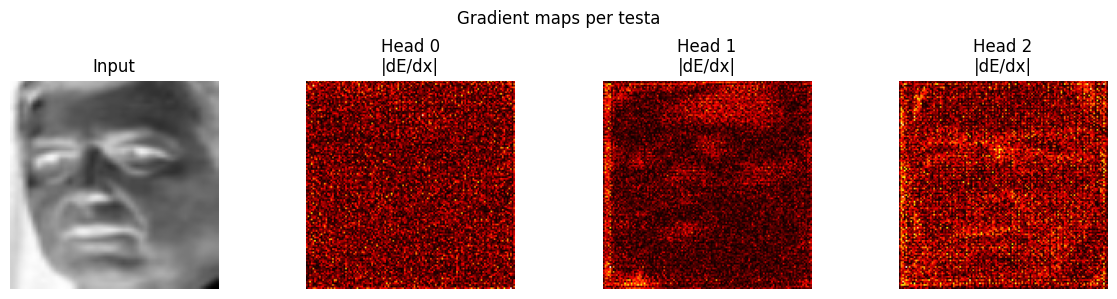

In [ ]:
it = iter(test_loader)

for _ in range(3):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_gradients(model.to(DEVICE), x0, DEVICE)


In [ ]:
from time import time_ns
torch.save(model.state_dict(), f"./models/fmnist/model_fmnist_c579_1epoch_{time_ns()}.pth")

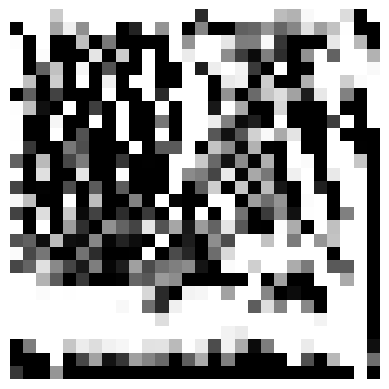

In [ ]:
from src.gradient_inspect import synthetize_image_from_head

img, _ = synthetize_image_from_head(model.heads[0].to("cpu"), n_images=1)
show_single_sample(img)
